In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [37]:
df = pd.read_csv('creditcard.csv')
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [38]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [39]:
scale = RobustScaler()
df['scaled_amount'] = scale.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scale.fit_transform(df['Time'].values.reshape(-1,1))

df = df.drop(columns=['Amount', 'Time'], axis = 1)

df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


C:\Users\91989\AppData\Local\Temp\ipykernel_10924\3350268285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2', ax=axes[0])


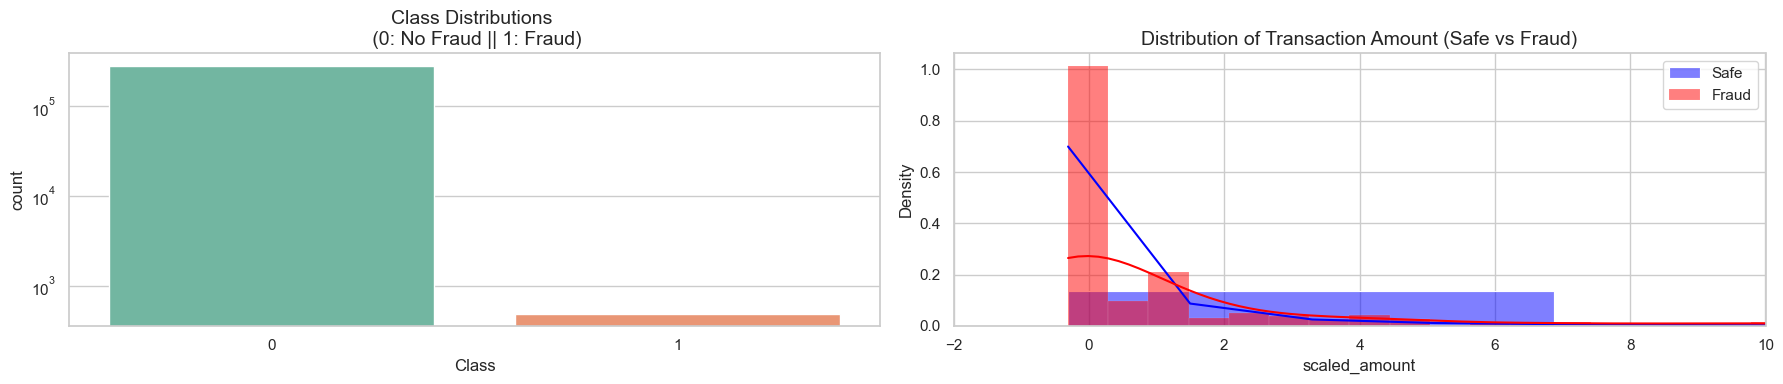

In [40]:
# Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# --- Plot 1: The Class Imbalance ---
sns.countplot(x='Class', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)
axes[0].set_yscale('log') # Log scale so the tiny fraud bar is visible!

# --- Plot 2: Distribution of Transaction Amounts ---
# Isolate the two classes using our newly scaled column
fraud_amount = df['scaled_amount'][df['Class'] == 1]
safe_amount = df['scaled_amount'][df['Class'] == 0]

sns.histplot(safe_amount, bins=50, color='blue', kde=True, stat="density", label='Safe', alpha=0.5, ax=axes[1])
sns.histplot(fraud_amount, bins=50, color='red', kde=True, stat="density", label='Fraud', alpha=0.5, ax=axes[1])

axes[1].set_title('Distribution of Transaction Amount (Safe vs Fraud)', fontsize=14)
axes[1].set_xlim([-2, 10]) # Zoom in on the most common transaction sizes
axes[1].legend()

plt.tight_layout()
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop(columns = ['Class'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=2)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- BEFORE SMOTE (Training Data Only) ---")
print(y_train.value_counts())

print("\n--- AFTER SMOTE (Training Data Only) ---")
print(y_train_smote.value_counts())


--- BEFORE SMOTE (Training Data Only) ---
Class
0    227437
1       408
Name: count, dtype: int64

--- AFTER SMOTE (Training Data Only) ---
Class
0    227437
1    227437
Name: count, dtype: int64


Making predictions on the real-world test set...

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56878
           1       0.41      0.88      0.56        84

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.78     56962
weighted avg       1.00      1.00      1.00     56962



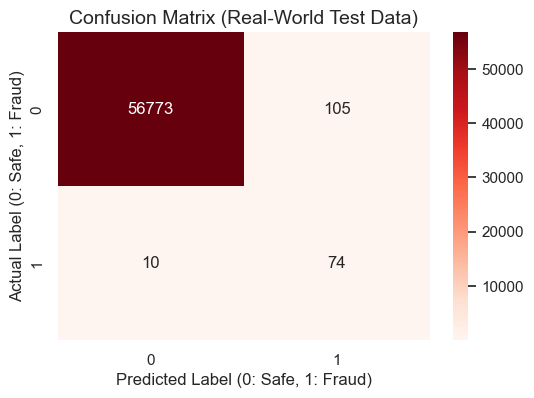

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model_rf = RandomForestClassifier(random_state = 42, n_jobs = -1, max_depth = 10)
model_rf.fit(X_train_smote, y_train_smote)

print("Making predictions on the real-world test set...")

y_pred_rf = model_rf.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix (Real-World Test Data)', fontsize=14)
plt.ylabel('Actual Label (0: Safe, 1: Fraud)')
plt.xlabel('Predicted Label (0: Safe, 1: Fraud)')
plt.show()

C:\Users\91989\AppData\Local\Temp\ipykernel_10924\415508853.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


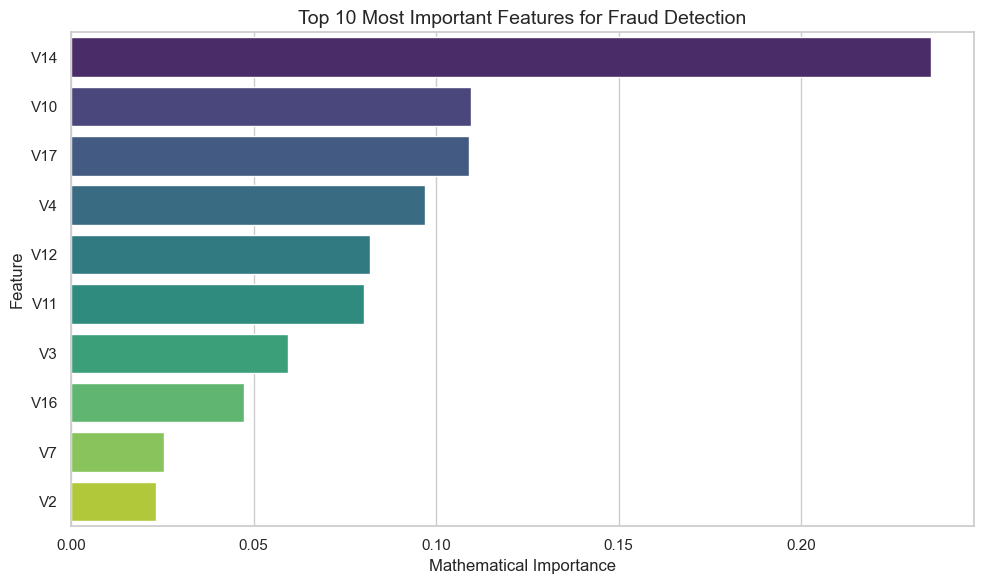

In [43]:
# Extract the feature importances from the trained model
importances = model.feature_importances_
features = X.columns

# Create a DataFrame and sort it
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 only

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Most Important Features for Fraud Detection', fontsize=14)
plt.xlabel('Mathematical Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [47]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 9.3 MB/s eta 0:00:11
   -- ------------------------------------- 6.0/101.7 MB 21.4 MB/s eta 0:00:05
   ---- ----------------------------------- 11.5/101.7 MB 23.8 MB/s eta 0:00:04
   ----- ---------------------------------- 14.4/101.7 MB 20.7 MB/s eta 0:00:05
   ------- -------------------------------- 20.2/101.7 MB 22.2 MB/s eta 0:00:04
   ---------- ----------------------------- 26.5/101.7 MB 23.7 MB/s eta 0:00:04
   ------------ --------------------------- 33.0/101.7 MB 24.9 MB/s eta 0:00:03
   -------------- ------------------------- 35.7/101.7 MB 25.4 MB/s eta 0:00:03
   ----------------- ---------------------- 44.0/101.7 MB 25.2 MB/s eta 0:00:03
   ------------------- -------------------- 50.6/101.7 MB 25.9 MB/s eta 0:00:02
   ---------------------- ----------------- 57.4/101.7 MB 26.5 MB/s eta 0:00:02
   ------------------------- -------------- 64.0/101

C:\Users\91989\anaconda3\envs\Machine_Learning\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:55:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metricsc" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Making predictions on the test set...

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56878
           1       0.75      0.83      0.79        84

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



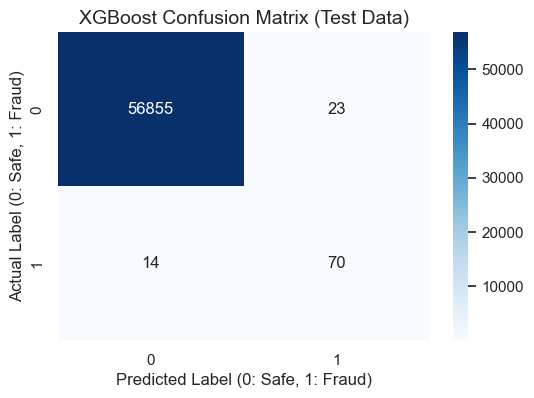

In [49]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metricsc='logloss')
xgb_model.fit(X_train_smote, y_train_smote)
print("Making predictions on the test set...")
y_pred_xgb = xgb_model.predict(X_test)

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix (Test Data)', fontsize=14)
plt.ylabel('Actual Label (0: Safe, 1: Fraud)')
plt.xlabel('Predicted Label (0: Safe, 1: Fraud)')
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'max_depth': [10, 20],
    'n_estimators': [100, 200]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                       param_grid=rf_params, 
                       scoring='f1', 
                       cv=3, 
                       verbose=2)

rf_grid.fit(X_train_smote, y_train_smote)
rf_best = rf_grid.best_estimator_

print(f"Best RF Parameters: {rf_grid.best_params_}\n")

xgb_params = {
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.2]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'), 
                        param_grid=xgb_params, 
                        scoring='f1', 
                        cv=3, 
                        verbose=2)

xgb_grid.fit(X_train_smote, y_train_smote)
xgb_best = xgb_grid.best_estimator_

print(f"Best XGB Parameters: {xgb_grid.best_params_}\n")

print("\n=== FINAL TEST SET EVALUATION ===")

print("\n[Challenger] Tuned Random Forest:")
rf_pred = rf_best.predict(X_test)
print(classification_report(y_test, rf_pred))

print("\n[Champion] Tuned XGBoost:")
xgb_pred = xgb_best.predict(X_test)
print(classification_report(y_test, xgb_pred))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .....................max_depth=10, n_estimators=100; total time=  49.0s
[CV] END .....................max_depth=10, n_estimators=100; total time=  40.4s
[CV] END .....................max_depth=10, n_estimators=100; total time=  40.1s
[CV] END .....................max_depth=10, n_estimators=200; total time= 1.3min
[CV] END .....................max_depth=10, n_estimators=200; total time= 1.4min
[CV] END .....................max_depth=10, n_estimators=200; total time= 1.3min
[CV] END .....................max_depth=20, n_estimators=100; total time=  58.1s
[CV] END .....................max_depth=20, n_estimators=100; total time=  55.7s
[CV] END .....................max_depth=20, n_estimators=100; total time=  57.0s
[CV] END .....................max_depth=20, n_estimators=200; total time= 1.9min
[CV] END .....................max_depth=20, n_estimators=200; total time= 1.9min
[CV] END .....................max_depth=20, n_est